**Import Packages:**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

**Define Functions for Analysis**

In [2]:
# Define gaussian filter subtraction and smoothing function
def gauss_sub(i):
    g = gaussian_filter1d(i,sigma=50) # Does a high standard deviation filter to get just the broadest background signal
    isub = i-g # Subtracts that background signal
    y = gaussian_filter1d(isub,sigma=2) # A low standard deviation filter to smooth out resulting spectrum
    return y

# Define function to get x and y position of peaks
def peaks(r,y,h):
    p = find_peaks(y,height=h,distance=20) # The Numpy find peaks function gives the intensity of the peaks
    py = p[1]['peak_heights'] # Get the y value of peak position
    px = r[p[0]] # Get the x value of peak position
    return px,py

# Define second gradient function
def second_gradient(y):
    dy = np.gradient(y) # Get gradient of intensity values
    yy = -gaussian_filter1d(np.gradient(dy),sigma=2) # Get inverse gradient of gradient and apply Gaussian smoothing function 
    return yy

# Define function to import data
def dataimport(path,h,hh,d): # Set path to the data file, minimum height for peak identification, and delimeter in data file
    a = np.genfromtxt(path,delimiter=d)
    r = a[:-75,0] # Array of raman shift 
    i = a[:-75,1] # Array of intensity
    y = gauss_sub(i) # Array of gaussian filter subtracted values
    yy = second_gradient(y) # Array for the second gradient of gaussian filter subtracted values
    px,py = peaks(r,y,h) # x and y coordinates of peaks for gaussian subtracted plot
    pxx,pyy = peaks(r,yy,hh) # x and y coordinates of peaks for 2nd gradient of gaussian subtracted plot
    return r,y,yy,px,py,pxx,pyy

**Import Data**

In [3]:
# Cultural (unknown) samples
n1r,n1y,n1yy,n1px,n1py,n1pxx,n1pyy = dataimport('Data/NN01_260130_Map_Average.txt',30,1,'\t')
n2r,n2y,n2yy,n2px,n2py,n2pxx,n2pyy = dataimport('Data/NN02_260128_Map_Average.txt',60,1,'\t')
n3r,n3y,n3yy,n3px,n3py,n3pxx,n3pyy = dataimport('Data/NN03_260130_Map_Average.txt',20,1,'\t')
n4ar,n4ay,n4ayy,n4apx,n4apy,n4apxx,n4apyy = dataimport('Data/NN04a_260306_MAP_20x20_Average.txt',50,1,'\t')
n4br,n4by,n4byy,n4bpx,n4bpy,n4bpxx,n4bpyy = dataimport('Data/NN04b_260306_MAP_20x20_Average.txt',20,1,'\t')
n5r,n5y,n5yy,n5px,n5py,n5pxx,n5pyy = dataimport('Data/NN05_260130_Map_Average.txt',50,1,'\t')
n6r,n6y,n6yy,n6px,n6py,n6pxx,n6pyy = dataimport('Data/NN06_260130_Map_Average.txt',30,1,'\t')
n7br,n7by,n7byy,n7bpx,n7bpy,n7bpxx,n7bpyy = dataimport('Data/NN07b_260306_MAP_20x20_Average.txt',30,1,'\t')

# Model (known) samples
kr,ky,kyy,kpx,kpy,kpxx,kpyy = dataimport('Data/M08_Kaolin_MapAvr_25-08-14.txt',85,1,'\t')
hr,hy,hyy,hpx,hpy,hpxx,hpyy = dataimport('Data/RRUFF_Hematite_R060190_Eng.txt',20,1.5,', ') # data taken from https://www.rruff.net/odr/rruff_sample#/odr/view/766245/2010/eyI3MDUyIjoiaGVtYXRpdGUiLCJkdF9pZCI6IjczOCIsInNvcnRfYnkiOlt7InNvcnRfZGZfaWQiOiI3MDUyIiwic29ydF9kaXIiOiJhc2MifV19/1
qr,qy,qyy,qpx,qpy,qpxx,qpyy = dataimport('Data/M1-Qua-MAP-250814_Average.txt',10,1,'\t')

**Define Functions for Plotting**

In [4]:
# Define function to put coloured vertical lines along x values of model samples peaks
def vertlines(px,py,color):
    for i,j in zip(px,py):
        plt.axvline(x=i,color=color,linewidth=0.7,ls='--',alpha=0.5)

# Define function to plot data
def ramplot(r,y,px,py,ymin,ymax,label,color,grad=None,model=None,top=None,bottom=None): # Set parameters for variables, y axis limits, labels, colour,
    frame1 = plt.gca()                                                                  # whether it is the Gauss sub plot or the 2 gradient plot, 
    plt.plot(r,y,c=color,linewidth=1) # Plot spectrum                                   # whether it is a model sample, and whether the subplot is at the top or bottom
    plt.plot(px,py,"x",c=color) # Plot peak positions
    if model:
        for i,j in zip(px,py): # Label the x position of the peaks for model samples
            plt.annotate(np.round(i,decimals=1),xy=(i,j),xytext=(4,0),textcoords='offset points',color=color)
    else:
        pass
    plt.xlim(180,700) # Set limits
    plt.ylim(ymin,ymax)
    plt.gca().yaxis.set_label_position("right") # Place the y axis on the right
    plt.ylabel(label,c=color) # Label the sample ID
    frame1.axes.get_yaxis().set_ticks([]) # Don't show ticks on axis
    frame1.axes.get_xaxis().set_ticks([])
    if top:
        pass
    else:
        frame1.spines['top'].set_visible(False) # Don't show top border unless its the top subplot
    if bottom:
        plt.xlabel('Raman Shift (cm-1)') # Set x axis label for bottom subplot
    else:
        frame1.spines['bottom'].set_visible(False) # Don't show bottom border unless its the bottom subplot
    if grad:
        vertlines(kpxx,kpyy,'Green') # Plot vertical lines
        vertlines(hpxx,hpyy,'Orange')
        vertlines(qpxx,qpyy,'Grey')
    else:
        vertlines(kpx,kpy,'Green')
        vertlines(hpx,hpy,'Orange')
        vertlines(qpx,qpy,'Grey')

**Set Plot Parameters**

In [5]:
plt.rcParams['font.sans-serif'] = 'IBM Plex Sans' # Set font
plt.rcParams['font.size'] = 9 # Set font size
plt.rcParams['figure.facecolor'] = 'White' # Set background colour
plt.rcParams['figure.dpi'] = 600 # Set figure resolution as DPI

**Create Gaussian Subtracted Plot**

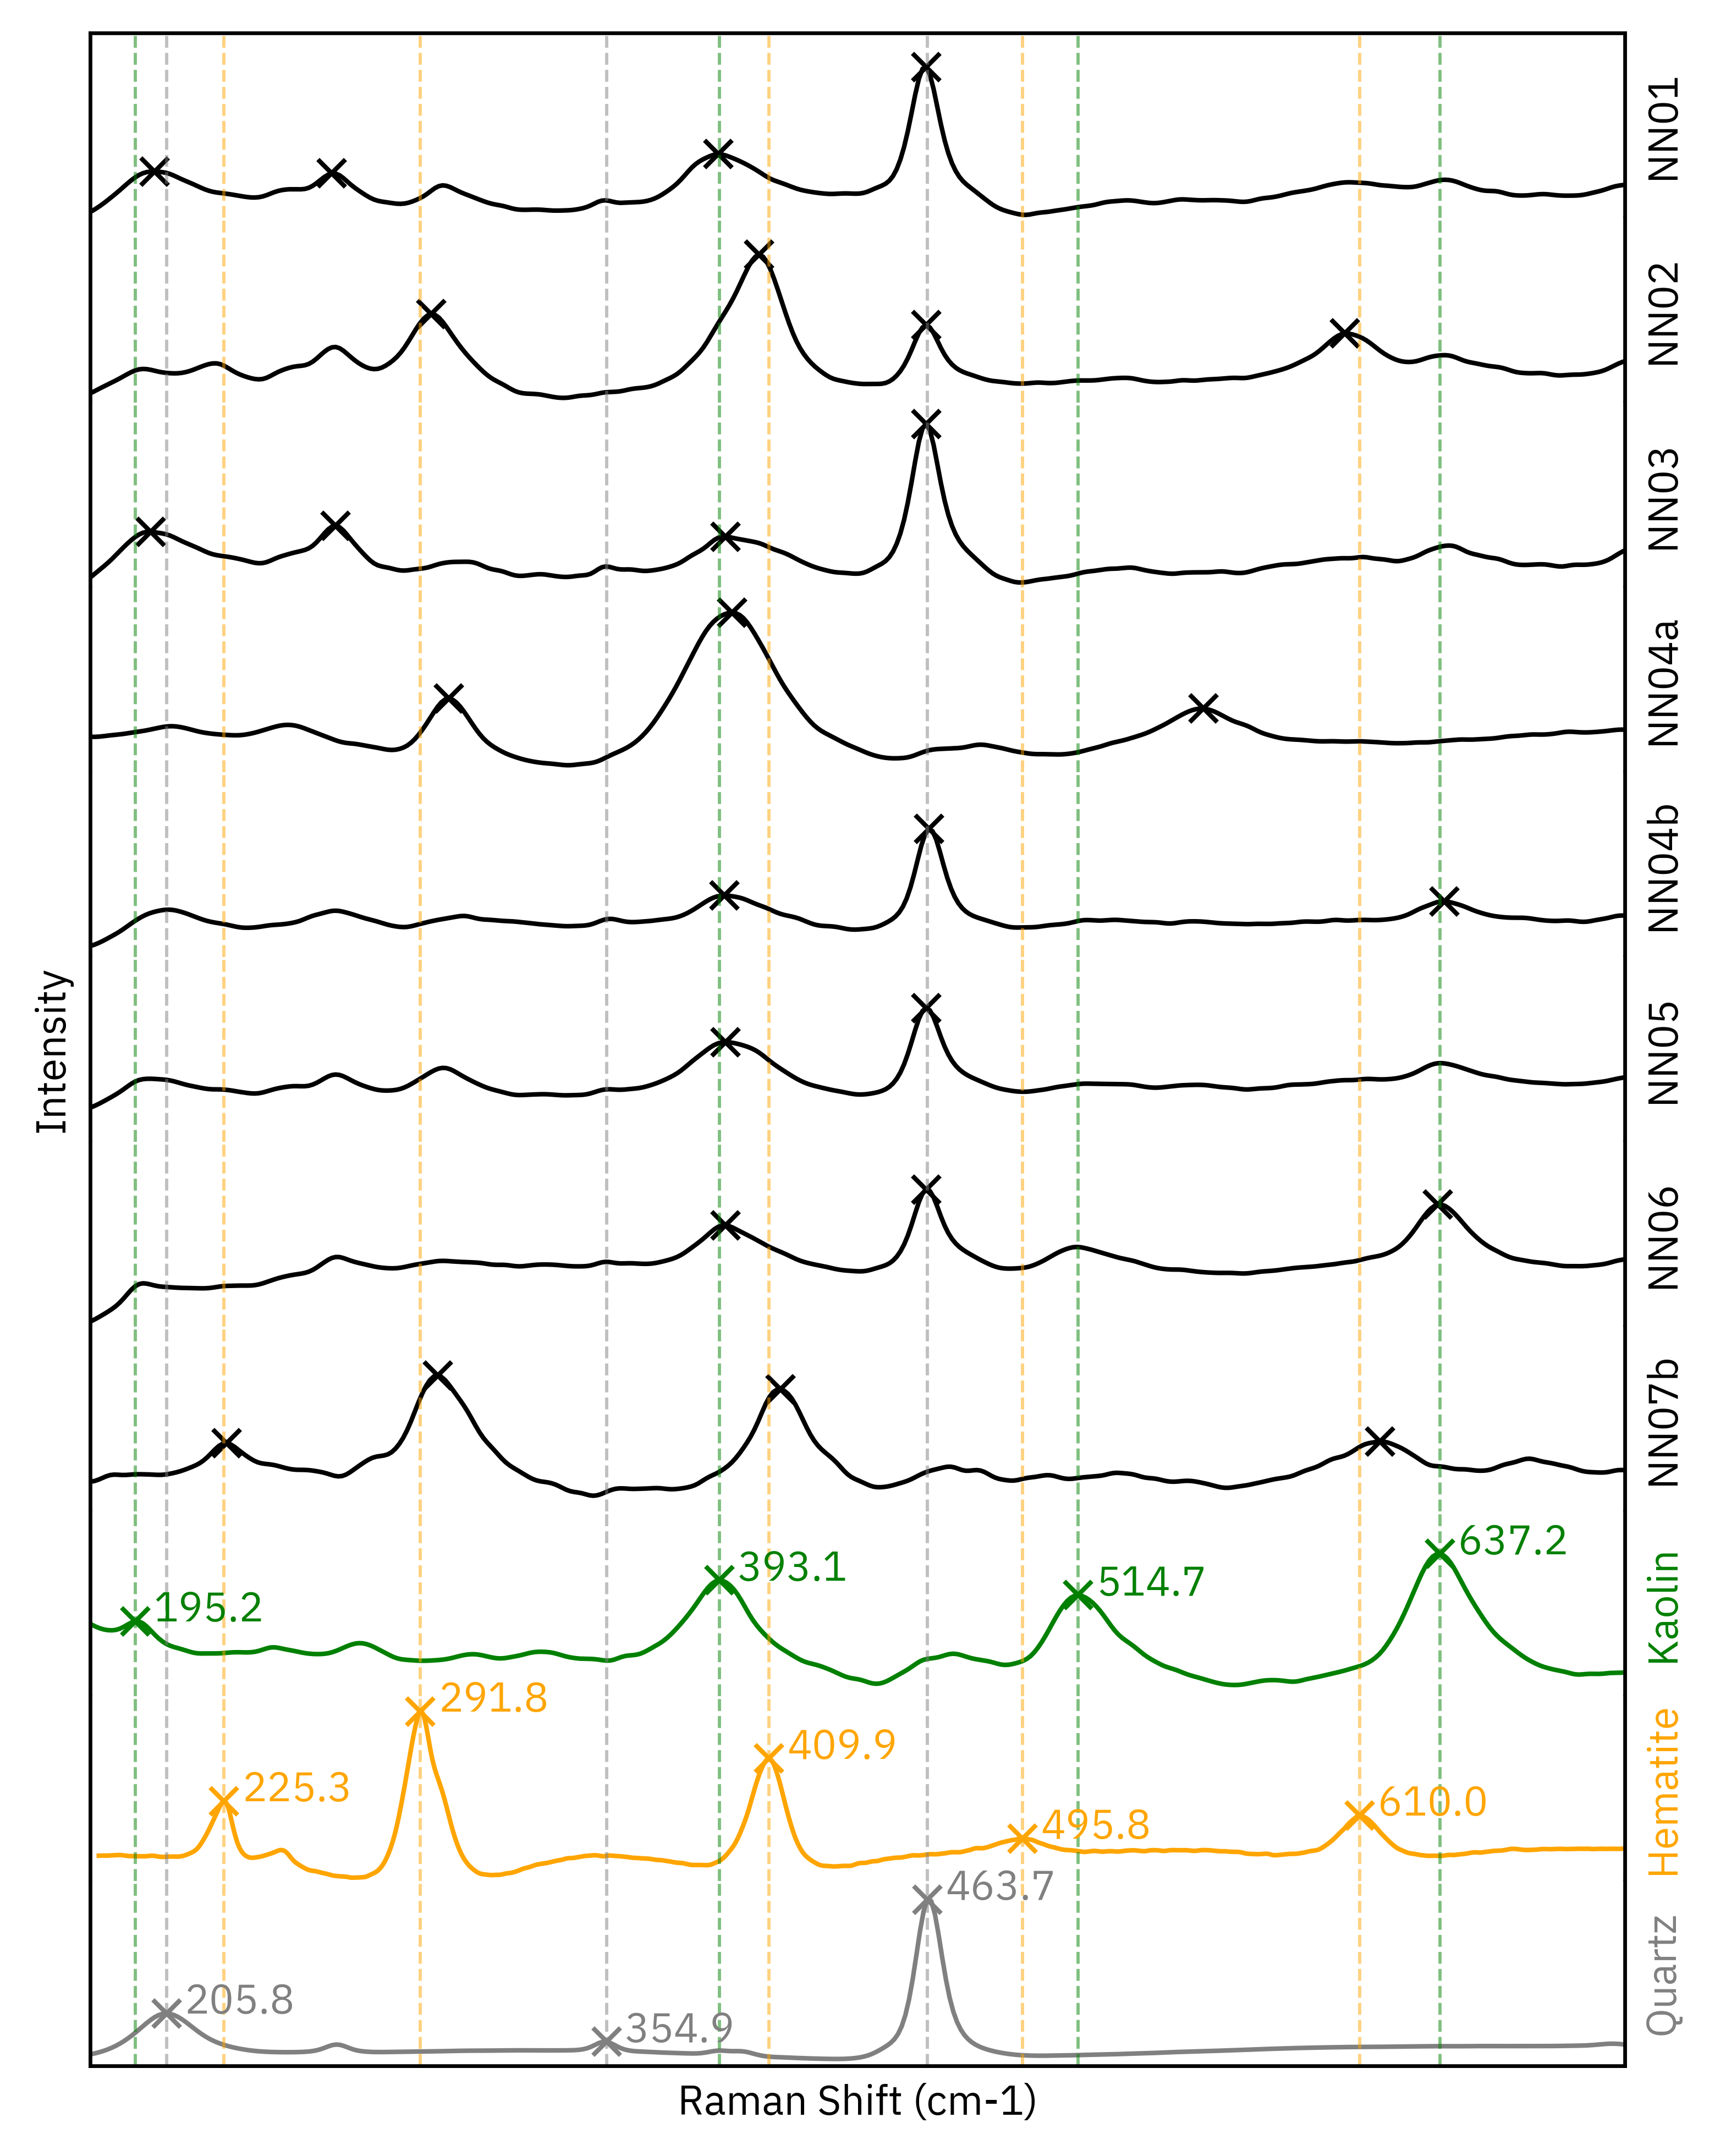

In [7]:
plt.figure(figsize=(6,8)) # Set dimensions of plot
plt.subplots_adjust(hspace=0) # Make subplots have no vertical space between them
frame1 = plt.gca() # Set frame for plot to not show ticks
frame1.axes.get_yaxis().set_ticks([])
frame1.axes.get_xaxis().set_ticks([])
plt.ylabel('Intensity') # Label y axis
b = 'Black' # Shortcut for efficiency

plt.subplot(11,1,1)
ramplot(n1r,n1y,n1px,n1py,-50,300,'NN01',b,top=True)

plt.subplot(11,1,2)
ramplot(n2r,n2y,n2px,n2py,-70,300,'NN02',b)

plt.subplot(11,1,3)
ramplot(n3r,n3y,n3px,n3py,-30,180,'NN03',b)

plt.subplot(11,1,4)
ramplot(n4ar,n4ay,n4apx,n4apy,-80,300,'NN04a',b)

plt.subplot(11,1,5)
ramplot(n4br,n4by,n4bpx,n4bpy,-60,220,'NN04b',b)

plt.subplot(11,1,6)
ramplot(n5r,n5y,n5px,n5py,-100,200,'NN05',b)

plt.subplot(11,1,7)
ramplot(n6r,n6y,n6px,n6py,-150,250,'NN06',b)

plt.subplot(11,1,8)
ramplot(n7br,n7by,n7bpx,n7bpy,-70,250,'NN07b',b)

plt.subplot(11,1,9)
ramplot(kr,ky,kpx,kpy,-120,400,'Kaolin','Green',model=True)

plt.subplot(11,1,10)
ramplot(hr,hy,hpx,hpy,-640,3000,'Hematite','Orange',model=True)

plt.subplot(11,1,11)
ramplot(qr,qy,qpx,qpy,-80,660,'Quartz','Grey',model=True,bottom=True)

**Create 2nd Gradient Plot**

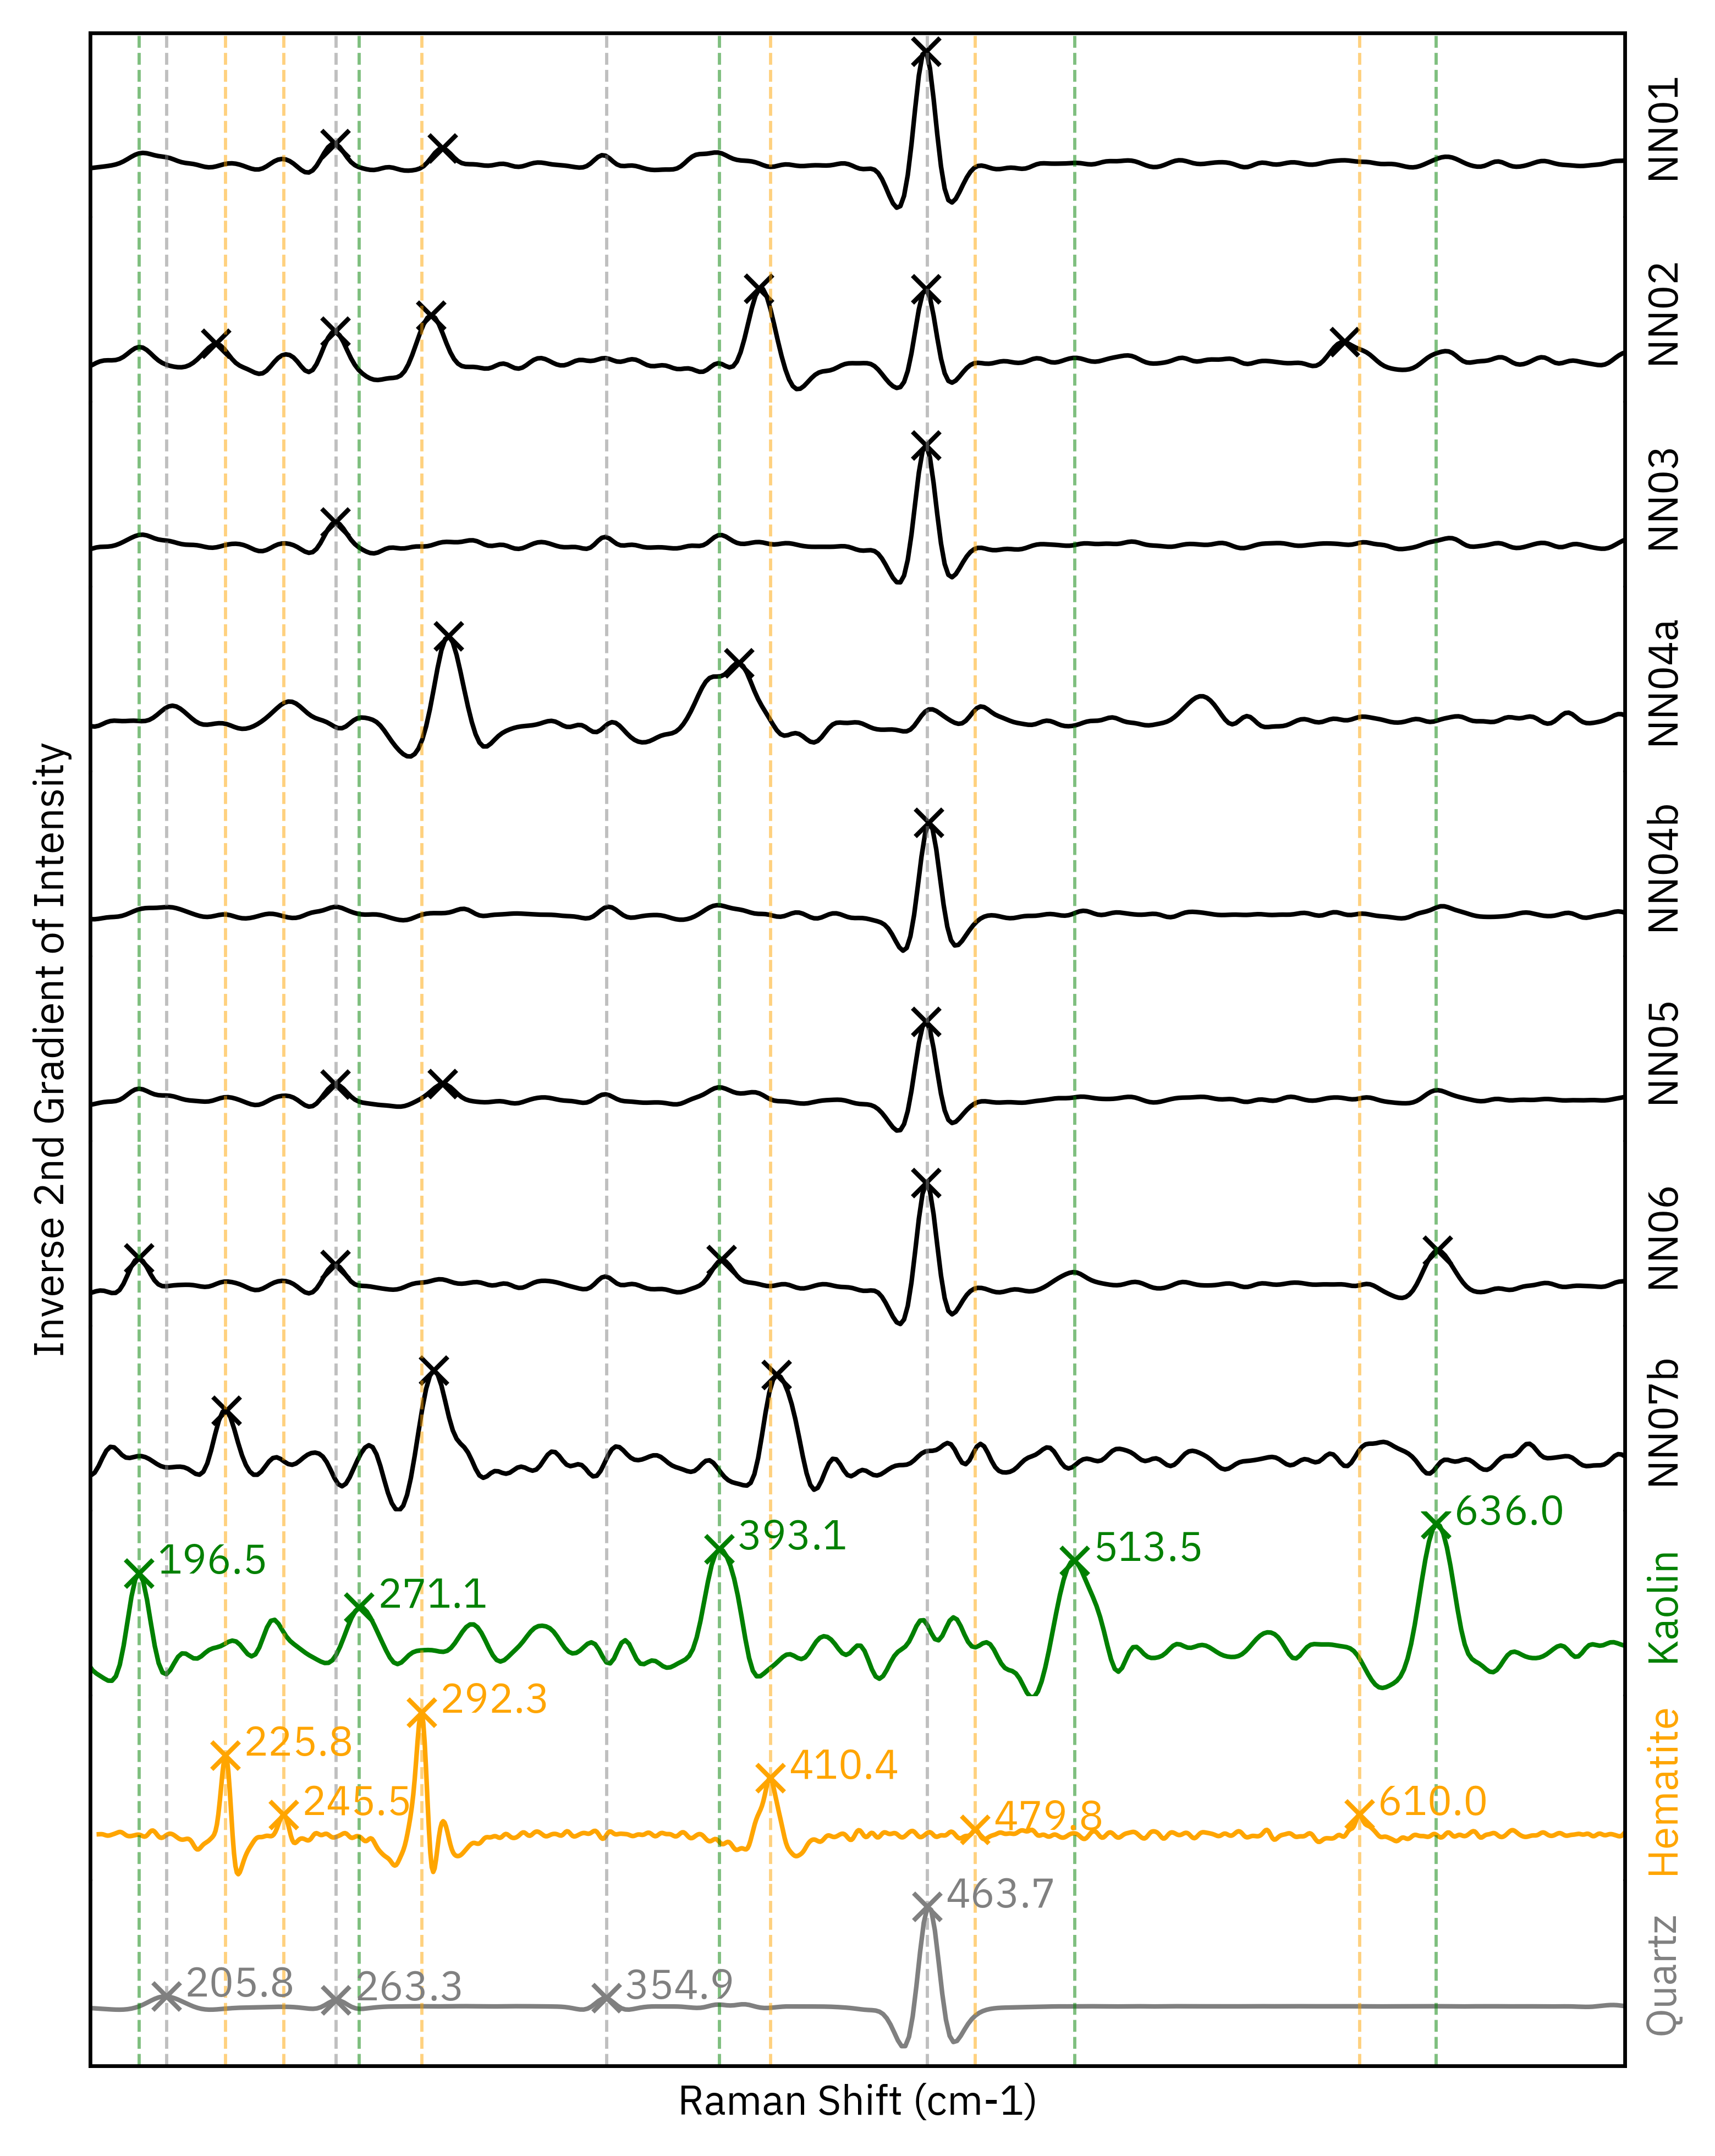

In [8]:
plt.figure(figsize=(6,8))
plt.subplots_adjust(hspace=0)
frame1 = plt.gca()
frame1.axes.get_yaxis().set_ticks([])
frame1.axes.get_xaxis().set_ticks([])
plt.ylabel('Inverse 2nd Gradient of Intensity')
b = 'Black'

plt.subplot(11,1,1)
ramplot(n1r,n1yy,n1pxx,n1pyy,-5,12,'NN01',b,grad=True,top=True)

plt.subplot(11,1,2)
ramplot(n2r,n2yy,n2pxx,n2pyy,-3,10,'NN02',b,grad=True)

plt.subplot(11,1,3)
ramplot(n3r,n3yy,n3pxx,n3pyy,-3,10,'NN03',b,grad=True)

plt.subplot(11,1,4)
ramplot(n4ar,n4ayy,n4apxx,n4apyy,-2,5,'NN04a',b,grad=True)

plt.subplot(11,1,5)
ramplot(n4br,n4byy,n4bpxx,n4bpyy,-3,10,'NN04b',b,grad=True)

plt.subplot(11,1,6)
ramplot(n5r,n5yy,n5pxx,n5pyy,-3,10,'NN05',b,grad=True)

plt.subplot(11,1,7)
ramplot(n6r,n6yy,n6pxx,n6pyy,-3,10,'NN06',b,grad=True)

plt.subplot(11,1,8)
ramplot(n7br,n7byy,n7bpxx,n7bpyy,-2,5,'NN07b',b,grad=True)

plt.subplot(11,1,9)
ramplot(kr,kyy,kpxx,kpyy,-2,5,'Kaolin','Green',grad=True,model=True)

plt.subplot(11,1,10)
ramplot(hr,hyy,hpxx,hpyy,-14,42,'Hematite','Orange',grad=True,model=True)

plt.subplot(11,1,11)
ramplot(qr,qyy,qpxx,qpyy,-17,36,'Quartz','Grey',grad=True,model=True,bottom=True)